# Modelo por hora — previsão de `qt_material` por hora × canal × categoria

**Objetivo:** testar se prever **por hora** (e somar as horas) melhora a previsão diária, e comparar o resultado com os outros dois modelos:
- `modelo_machine_learning_categorias.ipynb`: diário por canal × categoria (LightGBM, o modelo recomendado);
- `modelo_machine_learning_geral.ipynb`: diário do total (regressão linear).

**Mesmas regras do modelo por categoria**
- Mesmas correções de dados (agora em `44_sql_base_modelagem_hora.sql`, no grão hora × canal × categoria).
- Mesmas features: canal, categoria, dia da semana, dia do mês, uma coluna por data comemorativa, distância até a próxima e desde a última data, `black_november`, `campanha` e a premissa de **desconto semanal por canal × categoria**.
- Mesma validação faseada (14 dias à frente, 7 rodadas de 01/04 a 30/06), mesmos baselines no total do dia, mesmas duas etapas e mesmo quality gate.

**O que muda**
- **Hora do dia** como feature.
- **Lags do mesmo horário e mesmo dia da semana.** Como a previsão é feita **14 dias antes**, a semana mais recente disponível é a de **2 semanas antes**: o dado da semana imediatamente anterior ainda não existe quando prevemos a segunda semana do horizonte. Por isso usamos o mesmo horário de 2, 3 e 4 semanas antes e a média dos três. O lag de 1 semana só seria válido com horizonte de até 7 dias.

**Roteiro:** 1. Base · 2. Features · 3. Validação · 4. Baselines · 5. Etapa 1 · 6. Os lags ajudam? · 7. Comparação da etapa 1 · 8. Etapa 2 · 9. Resultado final · 10. SHAP · 11. Sensibilidade ao desconto · 12. Comparação dos três modelos · 13. Conclusões

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gb_ml.io import estimate_query_bytes, read_query

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ID = "gms-prod-01"
BQ_LOCATION = "us-east4"
TABLE_ID = "gms-prod-01.projeto_gb.fact_vendas"
STG_TABLE_ID = "gms-prod-01.projeto_gb.stg_fact_vendas"

START_DATE = "2025-11-01"
END_DATE = "2026-06-30"

DATE_FILTER = f"DATE(dt_hr_venda) BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'"

# Validação faseada: o teste começa depois de 5 meses de treino
INICIO_TESTE = "2026-04-01"

COR_REAL = "#333333"
CORES_MODELO = {
    "naive_sazonal": "#9e9e9e",
    "mm7": "#bdbdbd",
    "mm28": "#757575",
    "regressao_linear": "#1f4e79",
    "lightgbm": "#6a994e",
    "xgboost": "#d17a22",
    "vencedor_ajustado": "#a23b72",
    "categoria (diário)": "#6a994e",
    "geral (diário)": "#1f4e79",
    "horário": "#a23b72",
}

## Consumo BigQuery

Antes de cada consulta, fazemos um **dry-run** para estimar bytes processados. As consultas ficam na pasta `sql/`, numeradas na ordem de uso no projeto.

In [2]:
from pathlib import Path


def run_bq(sql: str, label: str | None = None) -> pd.DataFrame:
    bytes_processed = estimate_query_bytes(sql, project_id=PROJECT_ID, location=BQ_LOCATION)
    mb = bytes_processed / 1024**2
    print(f"[BigQuery] {label or 'query'} | estimativa processada: {mb:,.2f} MB")
    return read_query(sql, project_id=PROJECT_ID, location=BQ_LOCATION)


PASTA_SQL = next(
    pasta / "sql" for pasta in [Path.cwd(), *Path.cwd().parents] if (pasta / "sql").is_dir()
)


def carregar_sql(arquivo: str, **parametros) -> str:
    """Lê sql/<arquivo> e preenche os parâmetros {TABLE_ID}, {DATE_FILTER} etc."""
    modelo = (PASTA_SQL / arquivo).read_text(encoding="utf-8")
    return modelo.format(
        TABLE_ID=TABLE_ID,
        STG_TABLE_ID=STG_TABLE_ID,
        DATE_FILTER=DATE_FILTER,
        START_DATE=START_DATE,
        END_DATE=END_DATE,
        **parametros,
    )

# 1. Base de modelagem

`44_sql_base_modelagem_hora.sql` aplica as mesmas correções da base diária e completa a grade **hora × canal × categoria** com zero nas horas sem venda.

In [3]:
sql_base_modelagem_hora = carregar_sql("44_sql_base_modelagem_hora.sql")
base = run_bq(sql_base_modelagem_hora, "base de modelagem: hora x canal x categoria")
base["hora"] = pd.to_datetime(base["hora"])
base["data"] = pd.to_datetime(base["data"])
base["qt_material"] = base["qt_material"].astype(float)

print(f"{len(base):,} linhas | {base['hora'].nunique():,} horas | "
      f"{base.groupby(['des_canal_venda_final_agrup', 'des_categoria_material']).ngroups} séries | "
      f"{(base['qt_material'] == 0).mean():.1%} das linhas com zero venda")
display(base.head())

[BigQuery] base de modelagem: hora x canal x categoria | estimativa processada: 5.87 MB


104,544 linhas | 5,808 horas | 18 séries | 15.2% das linhas com zero venda


,hora,data,des_canal_venda_final_agrup,des_categoria_material,qt_material,receita_aprovada,vlr_venda_desconto,taxa_desconto_semana_canal_categoria
0,2025-11-01,2025-11-01,App,CABELOS,20.0000,668.6100,207.8000,0.3695
1,2025-11-01,2025-11-01,App,CORPO E BANHO,113.0000,"4,033.3000","2,091.4500",0.2981
2,2025-11-01,2025-11-01,App,FACIAL,20.0000,774.3400,524.4400,0.4926
3,2025-11-01,2025-11-01,App,GIFTS,43.0000,"3,532.3200","1,928.6700",0.3161
4,2025-11-01,2025-11-01,App,MAQUIAGEM,100.0000,"2,426.3700","2,201.7600",0.4161


### Conferência da base

A soma das horas precisa bater com a tabela original.

In [4]:
BASE_CONFERIDA = base

sql_conferencia_modelagem = carregar_sql("43_sql_conferencia_modelagem.sql")
original = run_bq(sql_conferencia_modelagem, "totais da tabela original").iloc[0]

conferencia = pd.DataFrame({
    "tabela original": original[["qt_material", "receita_aprovada", "vlr_venda_desconto"]].astype(float),
    "base de modelagem": BASE_CONFERIDA[["qt_material", "receita_aprovada", "vlr_venda_desconto"]].sum(),
})
conferencia["diferença"] = conferencia["base de modelagem"] - conferencia["tabela original"]
display(conferencia)
assert abs(conferencia.loc["qt_material", "diferença"]) < 1e-6, "a base perdeu ou duplicou volume"

[BigQuery] totais da tabela original | estimativa processada: 5.41 MB


,tabela original,base de modelagem,diferença
qt_material,"9,896,201.0000","9,896,201.0000",0.0000
receita_aprovada,"532,413,485.7000","532,413,485.7000",0.0000
vlr_venda_desconto,"379,767,342.7800","379,767,342.7800",0.0000


### Diagnóstico

- **Volume preservado:** a soma das horas bate exatamente com a tabela original (`qt_material`, receita e desconto).
- **Tamanho:** 104.544 linhas (5.808 horas × 18 séries), 24 vezes a base diária. Cerca de 15% das linhas têm venda zero, principalmente de madrugada e em séries pequenas.

# 2. Features

Todas as features do modelo diário por categoria, mais:

| Feature | Tipo | Por quê |
|---|---|---|
| `hora_dia` | 0 a 23 (dummies na regressão linear, referência 0h) | perfil de vendas ao longo do dia (seção 1.6 da análise exploratória) |
| `lag_2sem_mesma_hora`, `lag_3sem_mesma_hora`, `lag_4sem_mesma_hora` | volume da mesma série, mesma hora e mesmo dia da semana, 2, 3 e 4 semanas antes | o "dia da semana anterior" disponível com 14 dias de antecedência |
| `media_2a4sem_mesma_hora` | média dos três lags | reduz o ruído de uma hora isolada |

Os lags são testados como parâmetro (seção 6 e etapa 2). Mês e ano continuam fora, pelo mesmo motivo dos outros notebooks.

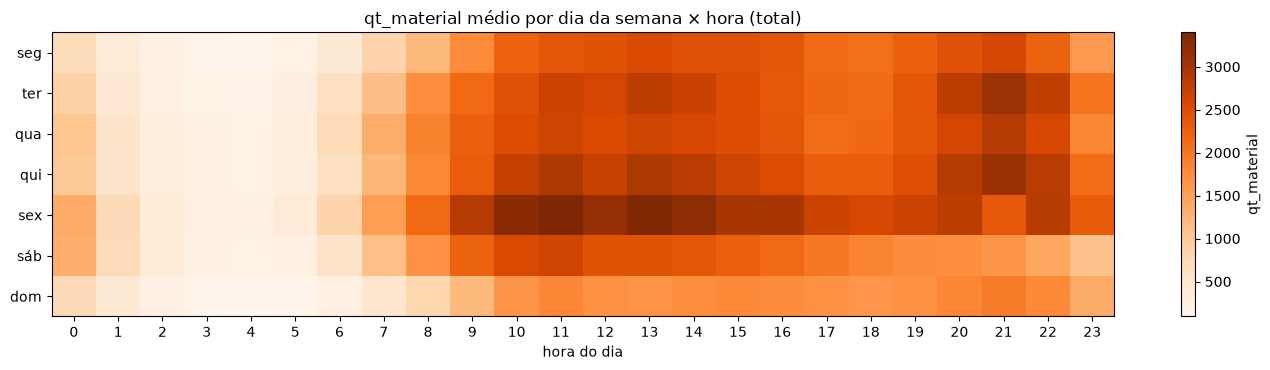

In [5]:
from gb_ml.features import COLUNA_DESCONTO, COLUNAS_LAG_HORA, montar_features_hora

df = montar_features_hora(base)

perfil = (
    df.groupby(["data", "dia_semana", "hora_dia"])["qt_material"].sum()
    .groupby(["dia_semana", "hora_dia"]).mean().unstack()
)
fig, ax = plt.subplots(figsize=(14, 3.8))
imagem = ax.imshow(perfil, aspect="auto", cmap="Oranges")
ax.set_yticks(range(7), ["seg", "ter", "qua", "qui", "sex", "sáb", "dom"])
ax.set_xticks(range(24))
ax.set_xlabel("hora do dia")
ax.set_title("qt_material médio por dia da semana × hora (total)")
plt.colorbar(imagem, ax=ax, label="qt_material")
plt.tight_layout()
plt.show()

### Diagnóstico

- **O perfil do dia é muito estável:** a madrugada (2h a 6h) tem quase nada, o volume sobe a partir das 8h e fica alto das 10h às 22h, com picos às 11h e às 21h.
- **Sexta-feira** concentra o maior volume no fim da manhã e começo da tarde; **domingo** é o dia mais fraco em todas as horas.
- Esse padrão se repete toda semana, então a hora do dia explica bem a distribuição dentro do dia, mas não muda o total do dia.

# 3. Validação faseada

Mesma regra do notebook por categoria: em cada rodada o modelo treina com **tudo que aconteceu até a véspera**, prevê os **próximos 14 dias** e só depois recebe esses 14 dias para a rodada seguinte (janela expansível). São 7 rodadas, de 01/04 a 30/06, com cerca de 5 meses de treino na primeira.

**Escolha do modelo em duas etapas**
1. **Etapa 1 — parâmetros padrão:** os três modelos (regressão linear, LightGBM, XGBoost) com os parâmetros padrão das bibliotecas.
2. **Etapa 2 — ajuste do vencedor:** antes de cada rodada, o vencedor testa uma grade de parâmetros nas 3 janelas de 14 dias anteriores (só dados até a véspera) e usa a melhor combinação. Se o ajuste não reduzir o erro, o modelo final fica com os parâmetros padrão.

**Métricas:** WAPE (Σ|erro| ÷ Σ real), MAE, viés (positivo = superestima) e skill contra o melhor baseline. **Quality gate:** skill > 0 e |viés| < 10% no total do dia.

**Neste notebook**, cada linha é uma hora de uma série. O WAPE por série (`wape_serie`) é medido na **hora × canal × categoria**. O WAPE do total do dia soma as 24 horas das 18 séries, então é comparável com os outros dois notebooks.

In [6]:
from gb_ml.model import (
    backtest_com_ajuste, baseline, buscar_parametros, dias_ineditos, erro_por_rodada,
    folds_de_ajuste, gerar_folds, metricas, metricas_complementares, resumo_backtest, rodar_backtest,
)

folds_teste = gerar_folds(INICIO_TESTE, END_DATE)
display(folds_teste.assign(dias_de_treino=(folds_teste["inicio"] - pd.Timestamp(START_DATE)).dt.days))


def plot_real_previsto(modelos: list[str], titulo: str, fonte: dict | None = None) -> None:
    """Total do dia: real × previsto por modelo, com as divisões das rodadas."""
    fonte = previsoes if fonte is None else fonte
    fig, ax = plt.subplots(figsize=(14, 4.5))
    real = fonte[modelos[0]].groupby("data")["qt_material"].sum()
    ax.plot(real.index, real, color=COR_REAL, lw=2, label="real")
    for modelo in modelos:
        previsto = fonte[modelo].groupby("data")["previsto"].sum()
        ax.plot(previsto.index, previsto, color=CORES_MODELO.get(modelo, "#7d5ba6"), lw=1.5, label=modelo)
    for inicio in folds_teste["inicio"]:
        ax.axvline(inicio, color="#999999", ls=":", lw=1)
    ax.set_title(titulo)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f} mil")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def tabela_comparacao(modelos: list[str], fonte: dict | None = None) -> pd.DataFrame:
    fonte = previsoes if fonte is None else fonte
    tabela = pd.DataFrame({m: resumo_backtest(fonte[m]) for m in modelos}).T
    tabela["skill_vs_baseline"] = 1 - tabela["wape_dia"] / WAPE_BASELINE
    tabela["passa_no_gate"] = (tabela["skill_vs_baseline"] > 0) & (tabela["vies_dia"].abs() < 0.10)
    return tabela.sort_values("wape_dia")


def plot_erro_rodada(modelos: list[str], titulo: str, fonte: dict | None = None) -> pd.DataFrame:
    fonte = previsoes if fonte is None else fonte
    fig, ax = plt.subplots(figsize=(14, 4))
    for modelo in modelos:
        rodadas = erro_por_rodada(fonte[modelo])
        ax.plot(rodadas["rodada"], rodadas["wape"], marker="o", color=CORES_MODELO.get(modelo, "#7d5ba6"), label=modelo)
    rotulos = [f"{r}\n{i:%d/%m}–{f:%d/%m}" for r, i, f in folds_teste[["rodada", "inicio", "fim"]].itertuples(index=False)]
    ax.set_xticks(folds_teste["rodada"], rotulos)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame({m: erro_por_rodada(fonte[m]).set_index("rodada")["wape"] for m in modelos})


def formatar_pct(tabela: pd.DataFrame) -> pd.DataFrame:
    return tabela.map(lambda v: ("—" if pd.isna(v) else f"{v:.1%}") if isinstance(v, float) else v)

,rodada,inicio,fim,dias_de_treino
0,1,2026-04-01,2026-04-14,151
1,2,2026-04-15,2026-04-28,165
2,3,2026-04-29,2026-05-12,179
3,4,2026-05-13,2026-05-26,193
4,5,2026-05-27,2026-06-09,207
5,6,2026-06-10,2026-06-23,221
6,7,2026-06-24,2026-06-30,235


# 4. Baselines

- **No total do dia:** os mesmos baselines dos outros notebooks (naive sazonal, mm7, mm28), calculados na base diária (soma das horas). São a referência do quality gate.
- **Na hora:** `naive_mesma_hora` repete o volume da mesma série, mesma hora e mesmo dia da semana de 2 semanas antes (o lag mais recente disponível).

In [7]:
from gb_ml.features import montar_features

base_dia = (
    base.groupby(["data", "des_canal_venda_final_agrup", "des_categoria_material"], as_index=False)
    .agg(qt_material=("qt_material", "sum"), receita_aprovada=("receita_aprovada", "sum"),
         vlr_venda_desconto=("vlr_venda_desconto", "sum"), **{COLUNA_DESCONTO: (COLUNA_DESCONTO, "first")})
)
df_dia = montar_features(base_dia)

previsoes = {}
for metodo in ["naive_sazonal", "mm7", "mm28"]:
    previsoes[metodo] = rodar_backtest(df_dia, folds_teste, baseline(metodo))
previsoes["naive_mesma_hora"] = rodar_backtest(
    df, folds_teste, lambda treino, teste: teste["lag_2sem_mesma_hora"].fillna(0).to_numpy()
)

resumo_baselines = pd.DataFrame({m: resumo_backtest(p) for m, p in previsoes.items()}).T
display(resumo_baselines)
MELHOR_BASELINE = resumo_baselines["wape_dia"].idxmin()
WAPE_BASELINE = resumo_baselines.loc[MELHOR_BASELINE, "wape_dia"]
print(f"Melhor baseline (WAPE do total do dia): {MELHOR_BASELINE}")

,wape_serie,wape_dia,mae_dia,vies_dia
naive_sazonal,0.5699,0.4113,"12,107.6593",-0.0027
mm7,0.5147,0.3576,"10,525.9011",-0.0027
mm28,0.5241,0.3868,"11,384.5137",0.0169
naive_mesma_hora,0.6727,0.4038,"11,884.5495",-0.0290


Melhor baseline (WAPE do total do dia): mm7


# 5. Etapa 1 — os três modelos com parâmetros padrão

Mesma configuração da etapa 1 do modelo por categoria, com a hora do dia nas features:

| Modelo | Configuração padrão |
|---|---|
| **Regressão linear** | mínimos quadrados, alvo em `log(1 + qt_material)`, dummies de hora, sem lags |
| **LightGBM** | parâmetros padrão da biblioteca, objetivo Poisson, sem lags |
| **XGBoost** | parâmetros padrão da biblioteca, objetivo Poisson, sem lags |

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
lightgbm,0.4837,0.2424,"7,133.5029",-0.0588,0.3223,True
xgboost,0.4652,0.2500,"7,357.6029",-0.0981,0.3010,True
regressao_linear,0.4914,0.3550,"10,449.5035",-0.3180,0.0073,False
naive_mesma_hora,0.6727,0.4038,"11,884.5495",-0.0290,-0.1291,False


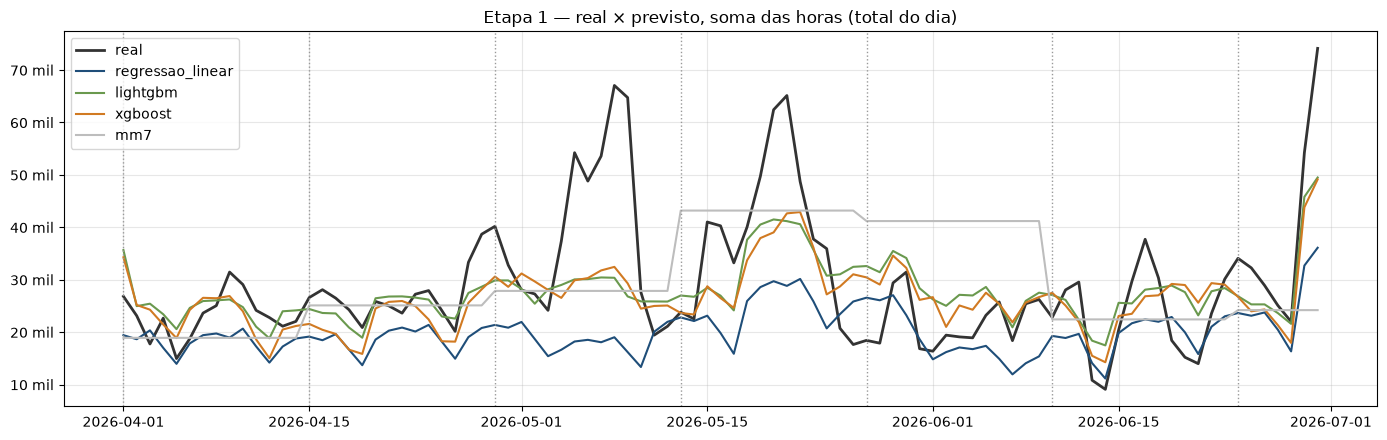

In [8]:
from functools import partial

from gb_ml.features import matriz_arvore_hora, matriz_linear_hora
from gb_ml.model import ajustar_linear, criar_lightgbm, criar_xgboost, lightgbm, linear, xgboost

FABRICAS = {
    "regressao_linear": partial(linear, matriz=matriz_linear_hora),
    "lightgbm": partial(lightgbm, matriz=matriz_arvore_hora),
    "xgboost": partial(xgboost, matriz=matriz_arvore_hora),
}
PADRAO = {
    "regressao_linear": {"alvo": "log", "usar_lags": False},
    "lightgbm": {"alvo": "poisson", "usar_lags": False},
    "xgboost": {"alvo": "poisson", "usar_lags": False},
}
for nome, fabrica in FABRICAS.items():
    previsoes[nome] = rodar_backtest(df, folds_teste, fabrica(**PADRAO[nome]))

display(tabela_comparacao([*FABRICAS, "naive_mesma_hora"]))
plot_real_previsto([*FABRICAS, MELHOR_BASELINE], "Etapa 1 — real × previsto, soma das horas (total do dia)")

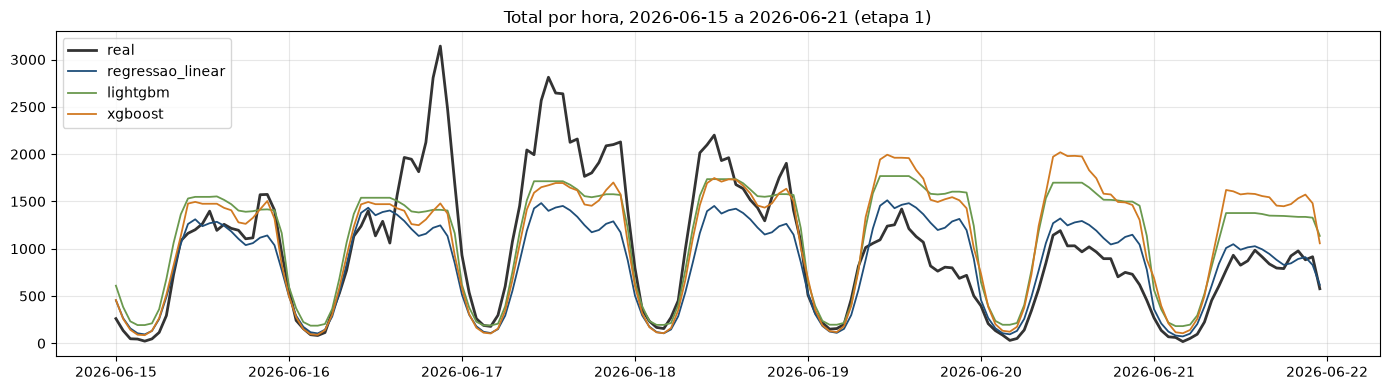

In [9]:
SEMANA_EXEMPLO = ("2026-06-15", "2026-06-21")


def plot_semana_horaria(fonte: dict, modelos: list[str], titulo: str) -> None:
    """Total por hora numa semana de exemplo: real × previsto."""
    fig, ax = plt.subplots(figsize=(14, 4))
    for i, modelo in enumerate(modelos):
        p = fonte[modelo]
        p = p[p["data"].between(*SEMANA_EXEMPLO)].groupby("hora")[["qt_material", "previsto"]].sum()
        if i == 0:
            ax.plot(p.index, p["qt_material"], color=COR_REAL, lw=2, label="real")
        ax.plot(p.index, p["previsto"], color=CORES_MODELO.get(modelo, "#7d5ba6"), lw=1.3, label=modelo)
    ax.set_title(titulo)
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_semana_horaria(previsoes, list(FABRICAS), f"Total por hora, {SEMANA_EXEMPLO[0]} a {SEMANA_EXEMPLO[1]} (etapa 1)")

### Resultados estatísticos da regressão

Efeitos da regressão ajustada com toda a base (efeito % = e^coeficiente − 1; desconto: +10 p.p.). As dummies de hora estão no gráfico, em relação à meia-noite.

R² = 0.730 | n = 104,544


,efeito_%,ic95_inf,ic95_sup,p_valor
is_app,1.4784,1.4478,1.5094,0.0000
taxa_desconto_semana_canal_categoria,0.4072,0.3970,0.4175,0.0000
evento_ano_novo,-0.2399,-0.2646,-0.2144,0.0000
evento_dia_consumidor,0.1976,0.1576,0.2390,0.0000
evento_dia_maes,0.6789,0.6247,0.7350,0.0000
evento_dia_namorados,0.2636,0.2234,0.3050,0.0000
evento_black_friday,0.0233,-0.0245,0.0735,0.3448
evento_natal,0.1426,0.1047,0.1818,0.0000
black_november,1.0716,1.0146,1.1302,0.0000
campanha,0.2432,0.2042,0.2835,0.0000


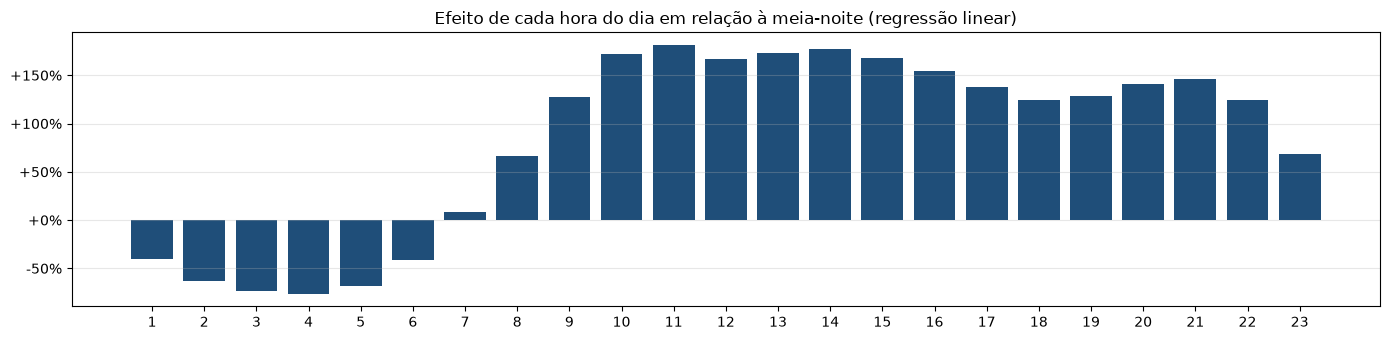

In [10]:
modelo_linear = ajustar_linear(df, **PADRAO["regressao_linear"], matriz=matriz_linear_hora)
print(f"R² = {modelo_linear.rsquared:.3f} | n = {int(modelo_linear.nobs):,}")
ic = modelo_linear.conf_int()
escala = pd.Series(1.0, index=modelo_linear.params.index)
escala[COLUNA_DESCONTO] = 0.10
efeitos = pd.DataFrame({
    "efeito_%": np.expm1(modelo_linear.params * escala),
    "ic95_inf": np.expm1(ic[0] * escala),
    "ic95_sup": np.expm1(ic[1] * escala),
    "p_valor": modelo_linear.pvalues,
})
display(efeitos.loc[[c for c in efeitos.index if c.startswith(("is_app", "taxa_", "evento_", "black_", "campanha", "dia_semana"))]])

horas = efeitos.loc[[c for c in efeitos.index if c.startswith("hora_")], "efeito_%"]
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(1, 24), horas.to_numpy(), color="#1f4e79")
ax.set_xticks(range(1, 24))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.set_title("Efeito de cada hora do dia em relação à meia-noite (regressão linear)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Esboço das árvores

Árvore substituta de 3 níveis ajustada às previsões de cada modelo de árvore (amostra de 20 mil linhas).

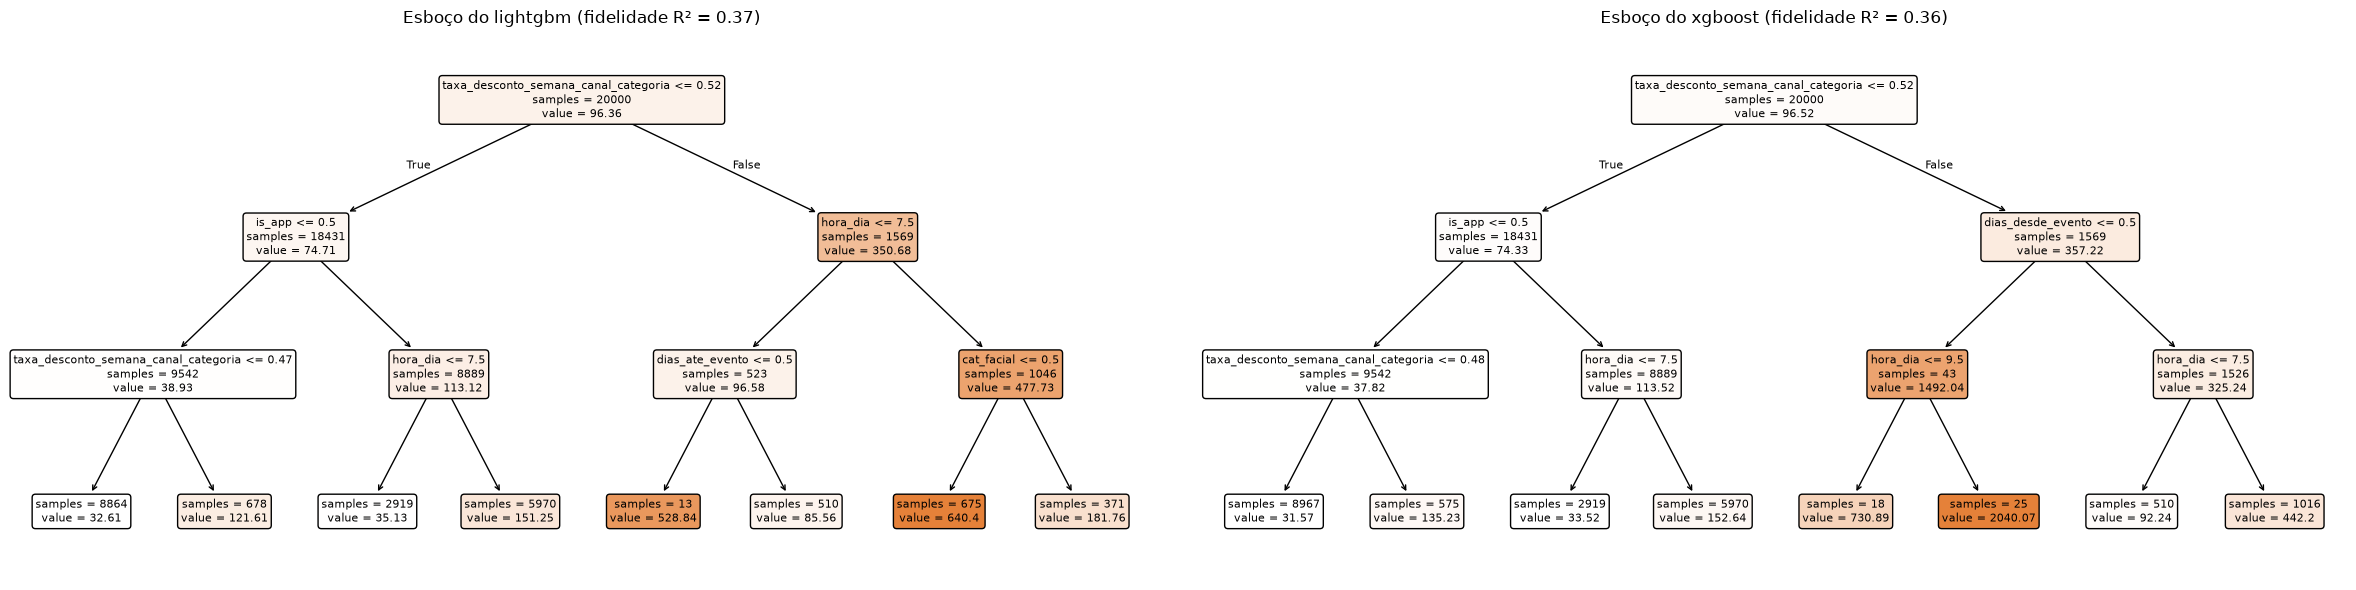

In [11]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

CRIAR = {"lightgbm": criar_lightgbm, "xgboost": criar_xgboost}


def treinar_arvore(nome: str, parametros: dict):
    extras = {k: v for k, v in parametros.items() if k not in ("alvo", "usar_lags")}
    X = matriz_arvore_hora(df, parametros["usar_lags"])
    y = np.log1p(df["qt_material"]) if parametros["alvo"] == "log" else df["qt_material"]
    modelo = CRIAR[nome](parametros["alvo"], **extras).fit(X, y)
    previsto = modelo.predict(X)
    return modelo, X, np.expm1(previsto) if parametros["alvo"] == "log" else previsto


amostra = df.sample(20_000, random_state=42).index
fig, eixos = plt.subplots(1, 2, figsize=(24, 6))
for ax, nome in zip(eixos, ["lightgbm", "xgboost"]):
    _, X, previsto = treinar_arvore(nome, PADRAO[nome])
    X, previsto = X.loc[amostra].fillna(-1), pd.Series(previsto, index=df.index).loc[amostra]
    esboco = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X, previsto)
    plot_tree(esboco, feature_names=list(X.columns), filled=True, rounded=True, impurity=False,
              precision=2, fontsize=8, ax=ax)
    ax.set_title(f"Esboço do {nome} (fidelidade R² = {esboco.score(X, previsto):.2f})")
plt.tight_layout()
plt.show()

### Diagnóstico

- **LightGBM vence:** WAPE do total do dia de **24,2%** (viés −5,9%), igual aos 24,2% do modelo diário por categoria. O XGBoost fica em 25,0%.
- **A regressão linear quase empata com o baseline** (35,5%, viés **−31,8%**). Com 15% de horas zeradas, o alvo em log puxa a média para baixo, e ao voltar para a escala de unidades a regressão subestima sistematicamente.
- **Na hora × série, o erro fica entre 47% e 49%** em todos os modelos: o ruído de uma hora isolada de uma categoria é grande.
- **Esboço das árvores:** desconto do canal × categoria → canal → **hora do dia (antes ou depois das 7h30)** → categoria e distância às datas. A árvore de 3 níveis explica só cerca de 37% do modelo, porque as horas criam muitas interações.
- **Efeitos da regressão:** iguais em sinal aos do modelo diário (desconto +10 p.p. → +41%, Black November +107%, Dia das Mães +68%).

# 6. Os lags ajudam?

Cada modelo roda de novo com os mesmos parâmetros padrão, agora **com** os lags do mesmo horário (2, 3 e 4 semanas antes e a média). Na regressão linear, os lags entram em log, e as primeiras 4 semanas (sem histórico, ou seja, quase toda a Black November) ficam fora do ajuste.

In [12]:
lags = []
for nome, fabrica in FABRICAS.items():
    previsoes[f"{nome} + lags"] = rodar_backtest(df, folds_teste, fabrica(**{**PADRAO[nome], "usar_lags": True}))
    for rotulo, chave in [("sem lags", nome), ("com lags", f"{nome} + lags")]:
        lags.append({"modelo": nome, "versão": rotulo, **resumo_backtest(previsoes[chave])})
lags = pd.DataFrame(lags).pivot(index="modelo", columns="versão", values=["wape_dia", "vies_dia", "wape_serie"])
display(formatar_pct(lags))

wape_dia          vies_dia          wape_serie         
versão           com lags sem lags com lags sem lags   com lags sem lags
modelo                                                                  
lightgbm            28.1%    24.2%    -9.6%    -5.9%      49.5%    48.4%
regressao_linear    37.4%    35.5%   -33.1%   -31.8%      50.0%    49.1%
xgboost             28.5%    25.0%   -11.6%    -9.8%      48.1%    46.5%

### Diagnóstico

- **Os lags do mesmo horário não ajudam:** o LightGBM vai de 24,2% para 28,1% e aumenta o viés (de −5,9% para −9,6%); o XGBoost e a regressão também pioram.
- **O motivo é o mesmo do modelo diário:** com 14 dias de antecedência, o lag mais recente é de 2 semanas antes. Ele repete eventos e picos de desconto daquela semana no lugar errado. O padrão "normal" da hora já é capturado por hora do dia, dia da semana e série.

# 7. Comparação da etapa 1

Vencedor: menor WAPE do total do dia na etapa 1 (parâmetros padrão, sem lags). Os lags voltam como parâmetro na etapa 2.

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
lightgbm,0.4837,0.2424,"7,133.5029",-0.0588,0.3223,True
xgboost,0.4652,0.2500,"7,357.6029",-0.0981,0.3010,True
regressao_linear,0.4914,0.3550,"10,449.5035",-0.3180,0.0073,False
mm7,0.5147,0.3576,"10,525.9011",-0.0027,0.0000,False
mm28,0.5241,0.3868,"11,384.5137",0.0169,-0.0816,False
naive_mesma_hora,0.6727,0.4038,"11,884.5495",-0.0290,-0.1291,False
naive_sazonal,0.5699,0.4113,"12,107.6593",-0.0027,-0.1503,False


Vencedor da etapa 1: lightgbm


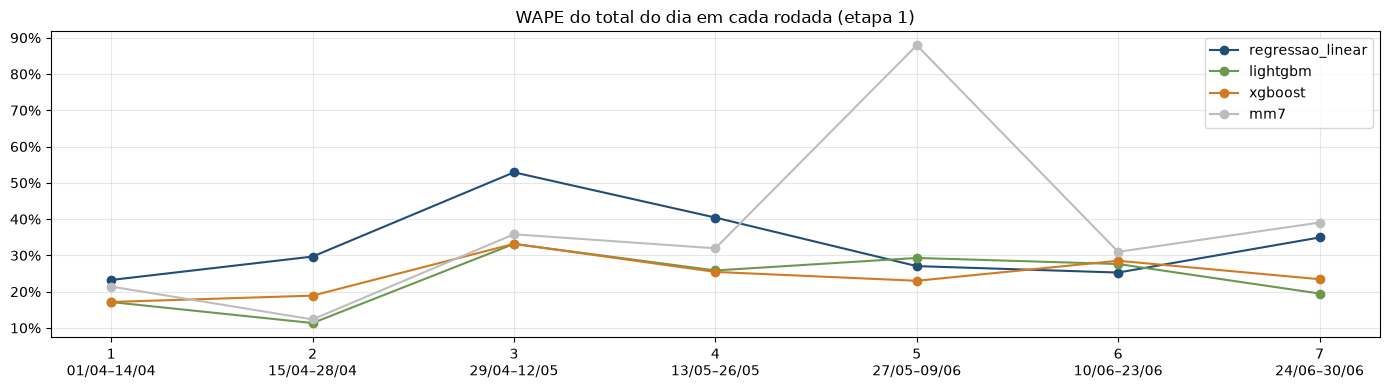

,regressao_linear,lightgbm,xgboost,mm7
rodada,,,,
1,23.2%,17.1%,17.2%,21.4%
2,29.7%,11.3%,18.9%,12.3%
3,52.9%,33.2%,33.2%,35.8%
4,40.4%,25.8%,25.4%,32.0%
5,27.0%,29.3%,23.0%,87.9%
6,25.3%,27.6%,28.5%,31.0%
7,34.9%,19.5%,23.4%,39.1%


In [13]:
etapa_1 = tabela_comparacao([*FABRICAS, "naive_mesma_hora", "naive_sazonal", "mm7", "mm28"])
display(etapa_1)
VENCEDOR = etapa_1.index[etapa_1.index.isin(FABRICAS)][0]
print(f"Vencedor da etapa 1: {VENCEDOR}")
display(formatar_pct(plot_erro_rodada([*FABRICAS, MELHOR_BASELINE], "WAPE do total do dia em cada rodada (etapa 1)")))

### Diagnóstico

- **Vencedor da etapa 1: LightGBM** (24,2%), seguido do XGBoost (25,0%). Os dois passam no gate; a regressão linear não.
- **Por rodada:** o comportamento é o mesmo dos modelos diários. A rodada do Dia das Mães (33,2%) concentra o maior erro, e nas demais o erro fica entre 11% e 29%.

# 8. Etapa 2 — ajuste do vencedor rodada a rodada

Antes de cada rodada de teste, o vencedor testa todas as combinações da grade nas **3 janelas de 14 dias imediatamente anteriores** (dados até a véspera) e usa a melhor para prever a rodada. Os parâmetros nunca são escolhidos olhando os dias que o modelo precisa acertar.

**Grades testadas.** A base horária tem 24 vezes mais linhas, então a grade das árvores foi reduzida para 16 combinações (contra 96 no modelo diário), mantendo os parâmetros que mais pesaram: tipo de alvo, lags, complexidade da árvore e número de árvores.
- **Regressão linear:** `alvo` em log ou nível; com ou sem lags.
- **LightGBM:** `alvo` (log ou Poisson), `usar_lags`, `num_leaves` (31 ou 63) e `n_estimators` (100 ou 300), com `learning_rate` 0,1.
- **XGBoost:** `alvo`, `usar_lags`, `max_depth` (6 ou 8) e `n_estimators` (100 ou 300), com `learning_rate` 0,1.

In [14]:
GRADES = {
    "regressao_linear": {"alvo": ["log", "nivel"], "usar_lags": [False, True]},
    "lightgbm": {
        "alvo": ["log", "poisson"],
        "usar_lags": [False, True],
        "num_leaves": [31, 63],
        "n_estimators": [100, 300],
        "learning_rate": [0.1],
    },
    "xgboost": {
        "alvo": ["log", "poisson"],
        "usar_lags": [False, True],
        "max_depth": [6, 8],
        "n_estimators": [100, 300],
        "learning_rate": [0.1],
    },
}

grade = GRADES[VENCEDOR]
print(f"{VENCEDOR}: {np.prod([len(v) for v in grade.values()])} combinações por rodada")

previsoes["vencedor_ajustado"], parametros_por_rodada = backtest_com_ajuste(
    df, folds_teste, FABRICAS[VENCEDOR], grade
)
print("Parâmetros escolhidos em cada rodada (só com o passado da rodada):")
display(parametros_por_rodada)

etapa_2 = tabela_comparacao([VENCEDOR, "vencedor_ajustado"])
etapa_2 = etapa_2.rename(index={VENCEDOR: f"{VENCEDOR} (padrão)", "vencedor_ajustado": f"{VENCEDOR} (ajustado)"})
display(etapa_2)

AJUSTE_AJUDA = (resumo_backtest(previsoes["vencedor_ajustado"])["wape_dia"]
                < resumo_backtest(previsoes[VENCEDOR])["wape_dia"])
if AJUSTE_AJUDA:
    proximo_dia = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)
    busca_final = buscar_parametros(df, folds_de_ajuste(proximo_dia), FABRICAS[VENCEDOR], grade)
    PARAMETROS_FINAIS = {**PADRAO[VENCEDOR], **{k: (v.item() if hasattr(v, "item") else v)
                                                 for k, v in busca_final.loc[0, list(grade)].items()}}
else:
    PARAMETROS_FINAIS = PADRAO[VENCEDOR]
MODELO_FINAL = "vencedor_ajustado" if AJUSTE_AJUDA else VENCEDOR
print("O ajuste reduz o erro?", "sim" if AJUSTE_AJUDA else "não — o modelo final fica com os parâmetros padrão")
print(f"Modelo final: {VENCEDOR} com {PARAMETROS_FINAIS}")

lightgbm: 16 combinações por rodada


Parâmetros escolhidos em cada rodada (só com o passado da rodada):


,rodada,alvo,usar_lags,num_leaves,n_estimators,learning_rate,wape_serie_ajuste
0,1,log,False,31,100,0.1000,0.4527
1,2,log,False,31,100,0.1000,0.4475
2,3,poisson,False,63,100,0.1000,0.4140
3,4,poisson,True,63,300,0.1000,0.4221
4,5,poisson,False,31,300,0.1000,0.4451
5,6,log,False,63,300,0.1000,0.4813
6,7,log,True,31,100,0.1000,0.4868


,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
lightgbm (padrão),0.4837,0.2424,"7,133.5029",-0.0588,0.3223,True
lightgbm (ajustado),0.4743,0.3024,"8,902.2389",-0.1872,0.1543,False


O ajuste reduz o erro? não — o modelo final fica com os parâmetros padrão
Modelo final: lightgbm com {'alvo': 'poisson', 'usar_lags': False}


### Diagnóstico

- **O ajuste piorou o LightGBM:** 30,2% contra 24,2% com os parâmetros padrão, e o viés foi para −18,7%. É o mesmo resultado do modelo diário: as janelas de 42 dias são curtas para escolher parâmetros de forma estável (a escolha mudou quase toda rodada).
- **Decisão:** o modelo final fica com os **parâmetros padrão** (Poisson, sem lags).

# 9. Resultado final

Métricas no total do dia (todos os dias, fora dos eventos inéditos e no total da semana) e na hora (hora × série e total da hora), comparadas aos baselines.

In [15]:
from gb_ml.features import COLUNAS_EVENTO

final = tabela_comparacao([*FABRICAS, "vencedor_ajustado", "naive_mesma_hora", MELHOR_BASELINE])
final = final.rename(index={"vencedor_ajustado": f"{VENCEDOR} (ajustado)"})
display(final)

INEDITOS = dias_ineditos(df_dia, folds_teste, COLUNAS_EVENTO)


def metricas_hora(p: pd.DataFrame) -> dict[str, float]:
    total_hora = p.groupby("hora")[["qt_material", "previsto"]].sum()
    return {
        "wape_hora_serie": metricas(p["qt_material"], p["previsto"])["wape"],
        "wape_hora_total": metricas(total_hora["qt_material"], total_hora["previsto"])["wape"],
    }


complementares = pd.DataFrame({
    f"horário — {VENCEDOR} (modelo final)": {**metricas_complementares(previsoes[MODELO_FINAL], INEDITOS),
                                             **metricas_hora(previsoes[MODELO_FINAL])},
    "naive_mesma_hora": {**metricas_complementares(previsoes["naive_mesma_hora"], INEDITOS),
                         **metricas_hora(previsoes["naive_mesma_hora"])},
    MELHOR_BASELINE: metricas_complementares(previsoes[MELHOR_BASELINE], INEDITOS),
}).T
display(formatar_pct(complementares))

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
lightgbm,0.4837,0.2424,"7,133.5029",-0.0588,0.3223,True
xgboost,0.4652,0.2500,"7,357.6029",-0.0981,0.3010,True
lightgbm (ajustado),0.4743,0.3024,"8,902.2389",-0.1872,0.1543,False
regressao_linear,0.4914,0.3550,"10,449.5035",-0.3180,0.0073,False
mm7,0.5147,0.3576,"10,525.9011",-0.0027,0.0000,False
naive_mesma_hora,0.6727,0.4038,"11,884.5495",-0.0290,-0.1291,False


,wape_dia,vies_dia,wape_dia_sem_ineditos,wape_semana,wape_hora_serie,wape_hora_total
horário — lightgbm (modelo final),24.2%,-5.9%,21.8%,19.0%,48.4%,29.4%
naive_mesma_hora,40.4%,-2.9%,41.1%,29.4%,67.3%,44.8%
mm7,35.8%,-0.3%,36.1%,30.3%,—,—


### Diagnóstico

- **Modelo horário final (LightGBM):**
  - total do dia: **24,2%**, com viés de −5,9% (passa no gate);
  - fora dos eventos inéditos: 21,8%;
  - total da semana: 19,0%.
- **Na hora:**
  - **total da hora:** 29,4%, contra 44,8% do `naive_mesma_hora`;
  - **hora × série:** 48,4%, contra 67,3%.
  - O modelo ganha bem do baseline horário, mas o erro de uma hora isolada continua alto: quase metade do volume.

# 10. SHAP — impacto de cada feature

Modelo final de árvore (ou LightGBM, se a regressão vencer) treinado com toda a base; SHAP calculado numa amostra de 5 mil linhas.

/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


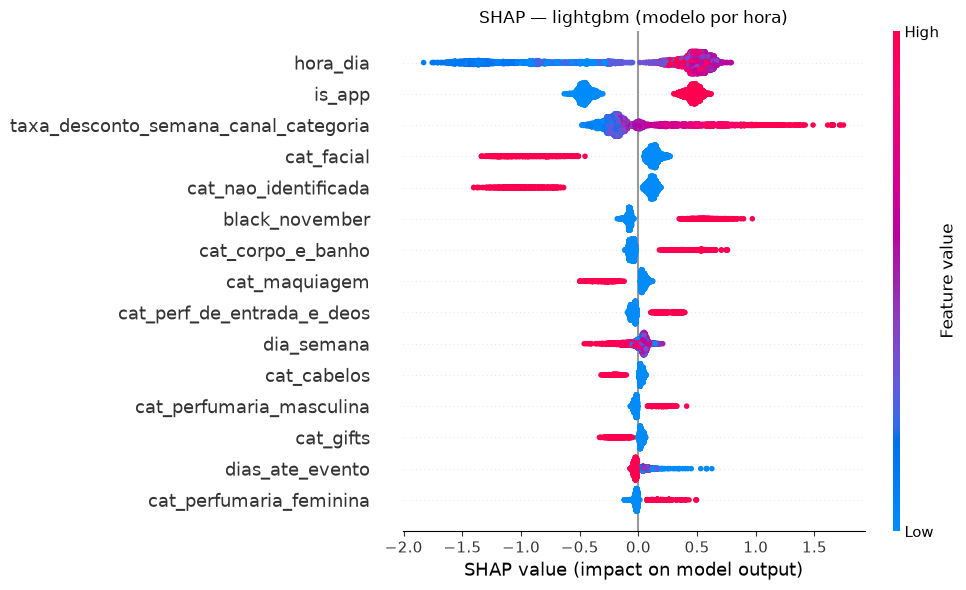

,participação
categoria,33.3%
hora_dia,25.1%
is_app,18.2%
taxa_desconto_semana_canal_categoria,11.4%
black_november,5.4%
dia_semana,2.4%
dias_ate_evento,1.6%
dia_mes,1.0%
evento_dia_maes,0.5%
dias_desde_evento,0.5%


In [16]:
import shap

nome_shap = VENCEDOR if VENCEDOR != "regressao_linear" else "lightgbm"
parametros_shap = PARAMETROS_FINAIS if nome_shap == VENCEDOR else PADRAO[nome_shap]
modelo, X, _ = treinar_arvore(nome_shap, parametros_shap)
X_amostra = X.sample(5_000, random_state=42)
valores = shap.TreeExplainer(modelo).shap_values(X_amostra)
plt.figure()
shap.summary_plot(valores, X_amostra, max_display=15, show=False, plot_size=(10, 6))
plt.title(f"SHAP — {nome_shap} (modelo por hora)")
plt.tight_layout()
plt.show()

impacto = pd.Series(np.abs(valores).mean(axis=0), index=X_amostra.columns)
grupos = impacto.groupby(impacto.index.map(
    lambda c: "categoria" if c.startswith("cat_") else ("lags (mesma hora)" if c.startswith(("lag_", "media_")) else c)
)).sum()
display((grupos / grupos.sum()).sort_values(ascending=False).map(lambda v: f"{v:.1%}").to_frame("participação"))

### Diagnóstico

- **Categoria (33%), hora do dia (25%) e canal (18%)** explicam cerca de 77% do impacto. Eles definem o nível de cada série em cada hora.
- **Desconto (11%) e Black November (5%)** explicam a variação ao longo do tempo, como no modelo diário.
- **Distância às datas (2%) e os eventos (menos de 1% cada)** pesam pouco. Os efeitos que mudam o total do dia são os mesmos do modelo diário. A hora só redistribui o volume dentro do dia.

# 11. Sensibilidade à premissa do desconto

Mesmos cenários do modelo por categoria, para o modelo final: plano **semanal sem abertura por categoria**, plano **mensal por categoria** e **sem desconto** (treino e teste sem a taxa).

In [17]:
def taxa(agrupamento) -> pd.Series:
    grupo = df.groupby(agrupamento)
    desconto = grupo["vlr_venda_desconto"].transform("sum")
    return desconto / (grupo["receita_aprovada"].transform("sum") + desconto)


cenarios = {
    "semanal sem abertura por categoria": taxa(df["data"].dt.to_period("W-SUN")),
    "mensal por categoria": taxa([df["data"].dt.to_period("M"), df["des_categoria_material"]]),
}


def com_taxa(ajustar_prever, taxa_cenario):
    def ajustar_prever_cenario(treino, teste):
        return ajustar_prever(treino, teste.assign(**{COLUNA_DESCONTO: taxa_cenario.loc[teste.index]}))
    return ajustar_prever_cenario


fabrica_final = FABRICAS[VENCEDOR](**PARAMETROS_FINAIS)
sensibilidade = {"premissa (semanal por categoria)": resumo_backtest(previsoes[MODELO_FINAL])["wape_dia"]}
for nome, taxa_cenario in cenarios.items():
    sensibilidade[nome] = resumo_backtest(rodar_backtest(df, folds_teste, com_taxa(fabrica_final, taxa_cenario)))["wape_dia"]
sensibilidade["sem desconto"] = resumo_backtest(
    rodar_backtest(df.assign(**{COLUNA_DESCONTO: 0.0}), folds_teste, fabrica_final))["wape_dia"]
sensibilidade[f"{MELHOR_BASELINE} (baseline)"] = WAPE_BASELINE
display(pd.Series(sensibilidade, name=f"WAPE do total do dia — {VENCEDOR}").map(lambda v: f"{v:.1%}").to_frame())

,WAPE do total do dia — lightgbm
premissa (semanal por categoria),24.2%
semanal sem abertura por categoria,23.3%
mensal por categoria,29.7%
sem desconto,32.5%
mm7 (baseline),35.8%


### Diagnóstico

- **Plano semanal sem abertura por categoria:** 23,3% (−0,9 p.p.): no grão horário, a taxa por série fica ruidosa e a média da semana funciona um pouco melhor.
- **Plano mensal por categoria:** 29,7% (+5,5 p.p.).
- **Sem desconto:** 32,5% (+8,3 p.p.), perto do mm7 (35,8%).
- **Mesma conclusão do modelo diário:** o detalhe semanal da premissa de desconto é o que mais importa.

# 12. Comparação dos três modelos

Recalculamos aqui os vencedores dos outros dois notebooks, nas mesmas rodadas:
- **categoria (diário):** LightGBM por canal × categoria, parâmetros padrão, objetivo Poisson, sem lags (`modelo_machine_learning.ipynb`);
- **geral (diário):** regressão linear no total do dia, alvo em log, sem lags (`modelo_machine_learning_geral.ipynb`);
- **horário:** o modelo final deste notebook.

**No dia:** todos são somados no total do dia.

**Na hora:** os modelos diários são repartidos pelas horas com o **perfil horário** (participação de cada hora nos 28 dias anteriores à rodada, por dia da semana; por série no modelo por categoria e no total no modelo geral). Assim dá para comparar também a precisão por hora.

Total do dia


,wape_dia,vies_dia,wape_dia_sem_ineditos,wape_semana
categoria (diário),24.2%,-6.8%,21.4%,17.9%
geral (diário),26.1%,-12.0%,20.2%,19.1%
horário,24.2%,-5.9%,21.8%,19.0%
mm7,35.8%,-0.3%,36.1%,30.3%


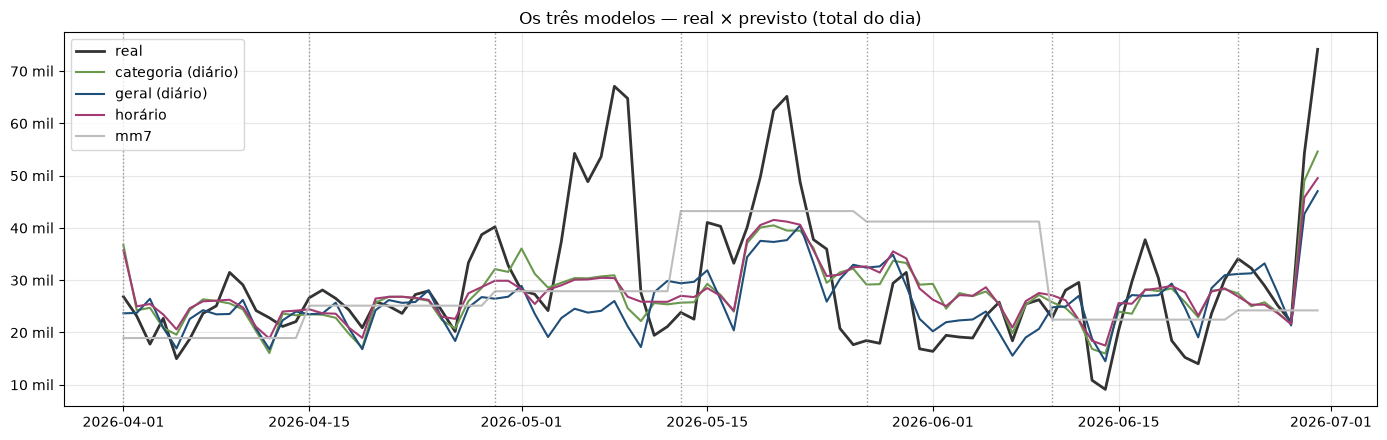

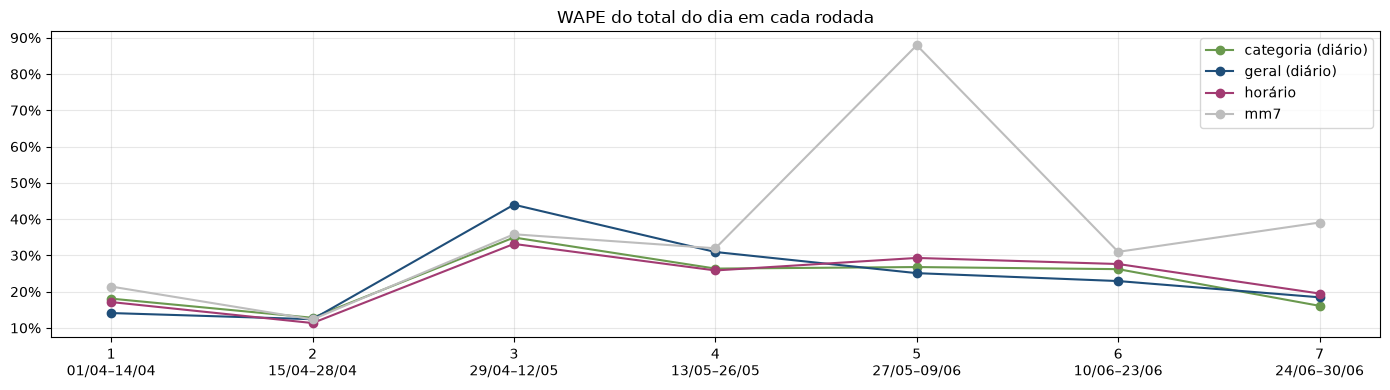

,categoria (diário),geral (diário),horário,mm7
rodada,,,,
1,18.1%,14.1%,17.1%,21.4%
2,12.8%,12.4%,11.3%,12.3%
3,34.9%,44.0%,33.2%,35.8%
4,26.4%,30.9%,25.8%,32.0%
5,26.8%,25.1%,29.3%,87.9%
6,26.2%,22.9%,27.6%,31.0%
7,16.1%,18.4%,19.5%,39.1%


In [18]:
from gb_ml.features import base_geral, distribuir_por_hora

df_geral = montar_features(base_geral(base_dia))
diarios = {
    "categoria (diário)": rodar_backtest(df_dia, folds_teste, lightgbm(alvo="poisson", usar_lags=False)),
    "geral (diário)": rodar_backtest(df_geral, folds_teste, linear(alvo="log")),
}
tres = {**diarios, "horário": previsoes[MODELO_FINAL], MELHOR_BASELINE: previsoes[MELHOR_BASELINE]}
no_dia = pd.DataFrame({nome: metricas_complementares(p, INEDITOS) for nome, p in tres.items()}).T
print("Total do dia")
display(formatar_pct(no_dia))
plot_real_previsto(list(tres), "Os três modelos — real × previsto (total do dia)", fonte=tres)
display(formatar_pct(plot_erro_rodada(list(tres), "WAPE do total do dia em cada rodada", fonte=tres)))

Na hora


,wape_hora_serie,wape_hora_total
categoria (diário) + perfil horário,48.7%,28.6%
geral (diário) + perfil horário,—,30.3%
horário,48.4%,29.4%
naive_mesma_hora,67.3%,44.8%


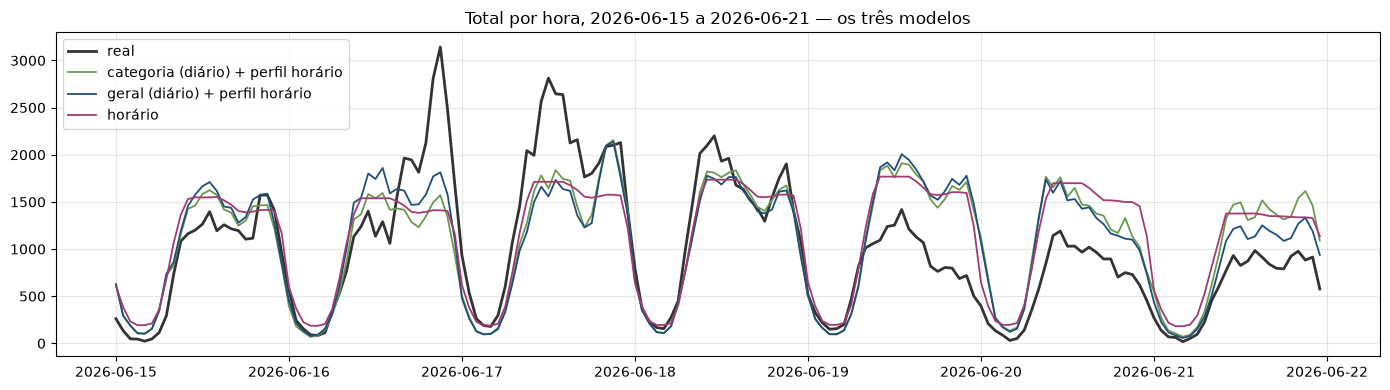

In [19]:
por_hora = {
    "categoria (diário) + perfil horário": distribuir_por_hora(diarios["categoria (diário)"], base, folds_teste),
    "geral (diário) + perfil horário": distribuir_por_hora(diarios["geral (diário)"], base, folds_teste, chave=[]),
    "horário": previsoes[MODELO_FINAL],
    "naive_mesma_hora": previsoes["naive_mesma_hora"],
}
na_hora = pd.DataFrame({nome: metricas_hora(p) for nome, p in por_hora.items()}).T
na_hora.loc["geral (diário) + perfil horário", "wape_hora_serie"] = np.nan  # o geral não tem série
print("Na hora")
display(na_hora.map(lambda v: "—" if pd.isna(v) else f"{v:.1%}"))

CORES_MODELO.update({"categoria (diário) + perfil horário": "#6a994e", "geral (diário) + perfil horário": "#1f4e79"})
plot_semana_horaria(por_hora, ["categoria (diário) + perfil horário", "geral (diário) + perfil horário", "horário"],
                    f"Total por hora, {SEMANA_EXEMPLO[0]} a {SEMANA_EXEMPLO[1]} — os três modelos")

### Resposta

**Diferença entre os três modelos**

| | Categoria (diário) | Geral (diário) | Horário |
|---|---|---|---|
| WAPE do total do dia | **24,2%** | 26,1% | **24,2%** |
| Viés | −6,8% | −12,0% | **−5,9%** |
| WAPE sem eventos inéditos | 21,4% | **20,2%** | 21,8% |
| WAPE do total da semana | **17,9%** | 19,1% | 19,0% |
| WAPE do total da hora | **28,6%** (com perfil horário) | 30,3% (com perfil horário) | 29,4% |
| WAPE da hora × série | 48,7% (com perfil horário) | — | 48,4% |
| Passa no quality gate | ✅ | ❌ | ✅ |
| Linhas de treino | ~4 mil | 242 | ~104 mil |

- **No total do dia, categoria e horário empatam** (24,2%), e o geral fica 1,9 p.p. atrás com viés fora do gate.
- **Na hora, o modelo horário não ganha nada:** repartir a previsão diária pelo perfil horário dos últimos 28 dias dá erro igual ou menor por hora (28,6% contra 29,4% no total da hora; 48,7% contra 48,4% na hora × série).
- **O erro de uma hora isolada de uma série fica perto de 48%** em qualquer abordagem: é ruído do grão, não falta de modelo.
- **Os lags do mesmo horário não ajudaram,** porque com 14 dias de antecedência o dado mais recente é de 2 semanas antes.
- **Custo:** o horário treina com 24 vezes mais linhas, leva bem mais tempo e exige uma base horária.

**Recomendação:** manter o **modelo diário por categoria** e, quando o negócio precisar de visão por hora, repartir a previsão pelo perfil horário recente. Isso entrega a mesma precisão por hora que o modelo horário, com uma fração do custo. O modelo geral serve como referência de sanidade do total.

# 13. Conclusões

- **Prever por hora não melhora o dia nem a hora:** os efeitos que movem as vendas (desconto, eventos, campanhas, dia da semana) são diários, e o perfil dentro do dia é estável. A hora acrescenta linhas e ruído, mas não informação nova.
- **Lags do mesmo horário:** com horizonte de 14 dias, só existem a partir de 2 semanas antes e não ajudam. Um lag de 1 semana só faria sentido com previsão de até 7 dias. Vale testar se o negócio precisar de um horizonte mais curto.
- **Regressão linear por hora não serve:** com muitas horas zeradas, o alvo em log gera subestimação forte (−32%).
- **Recomendação final dos três notebooks:** modelo **diário por categoria (LightGBM)** como previsão oficial, com o **perfil horário** quando for preciso abrir por hora e o **modelo geral** como checagem do total.